# Viscosity profile

In [1]:
using CairoMakie, GeoParams

thickness = 2890 * km
η0 = 9.8e21
CharDim = GEO_units(;
    length = thickness, viscosity = η0, temperature = 2.800e3K
)

n  = 64
lz = nondimensionalize(2890km, CharDim)
z  = LinRange(-lz, 0, n)


64-element LinRange{Float64, Int64}:
 -1.0, -0.984127, -0.968254, -0.952381, …, -0.031746, -0.015873, 0.0

### Diffusion viscosity

$\eta_{\text{diff}} = A^{-1} \exp( \frac{E + PV}{R  T})$

In [2]:
visc_diff(T, P, A, E, V; R = 8.3145) = A^(-1) * exp((E + P*V) / (R * T))
visc_diff(T, P, data::NamedTuple; R = 8.3145) = visc_diff(T, P, data.A, data.E, data.V; R = R)

visc_diff (generic function with 2 methods)

### Dislocation viscosity

$\eta_{\text{diff}} = \dot{\varepsilon}_{II}^{\frac{1-n}{n}} A^{\frac{-1}{n}} \exp( \frac{E + PV}{n R  T})$

In [3]:
visc_disl(εII, T, P, n, A, E, V; R = 8.3145) = εII^((1-n)/n) * A^(-1/n) * exp((E + P*V) / (n * R * T))
visc_disl(εII, T, P, data::NamedTuple; R = 8.3145) = visc_disl(εII, T, P, data.n, data.A, data.E, data.V; R = R)

visc_disl (generic function with 2 methods)

## Effective viscosity

$\eta = \frac{1}{\frac{1}{\eta}  + \frac{1}{\eta}}$

In [4]:
function visc_eff(εII, T, P,  data_diff::NamedTuple, data_disl::NamedTuple; R = 8.3145)
    η_diff = visc_diff(T, P, data_diff; R = R)
    η_disl = visc_disl(εII, T, P, data_disl; R = R)
    return η_diff * η_disl / (η_diff +  η_disl)
    return 1 / (1/η_diff +  1/η_disl)
end
function visc_eff(εII, T, P, ::Nothing, data_disl::NamedTuple; R = 8.3145)
    η_disl = visc_disl(εII, T, P, data_disl; R = R)
end
function visc_eff(εII, T, P, data_diff::NamedTuple, ::Nothing; R = 8.3145)
    η_diff = visc_diff(T, P, data_diff; R = R)
end


visc_eff (generic function with 3 methods)

## Initial thermal and pressure profiles

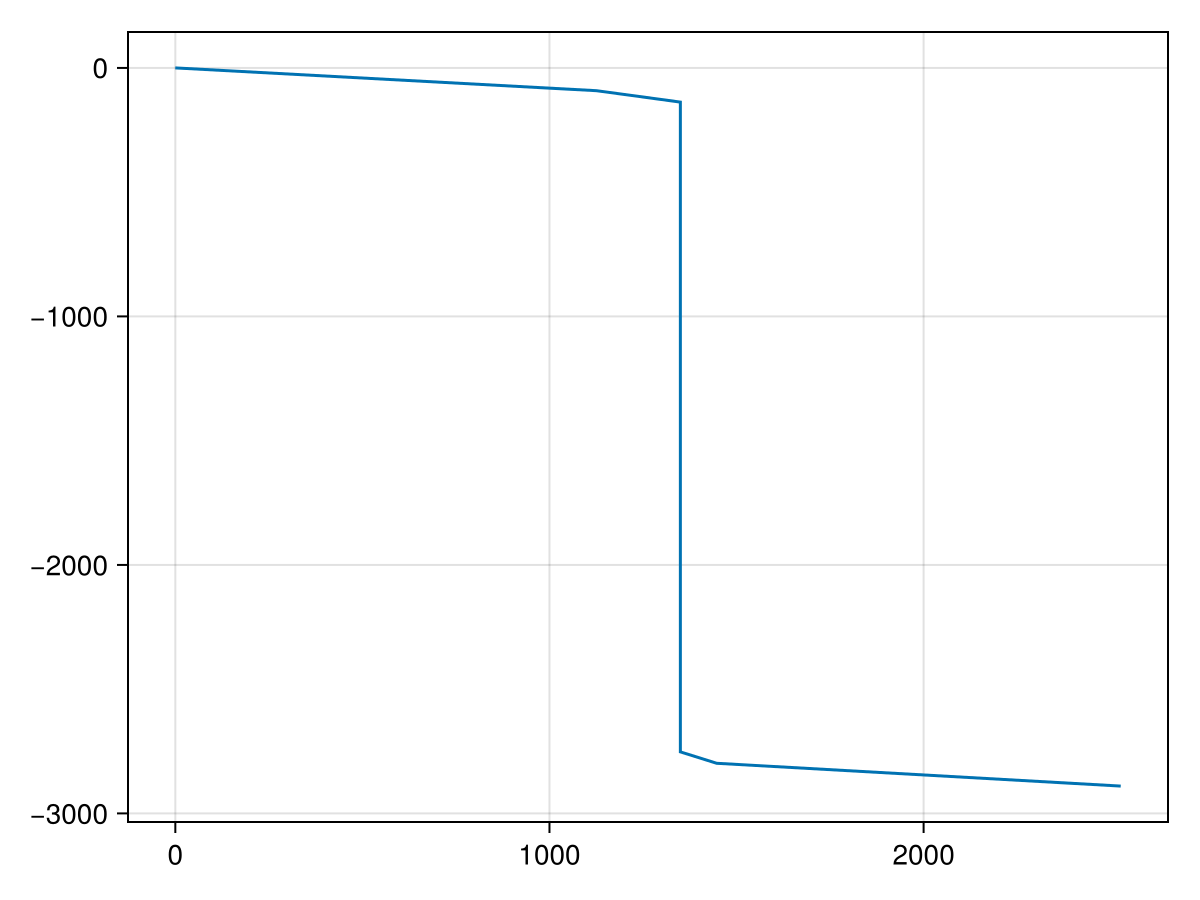

In [125]:
# Smooth switch
S(ξ) = 0.5 * (1.0 + tanh(ξ))

function T_field(
    z;
    Lz=2890.0,
    n=1,
    m=1,
    Ttop=273.0,
    Tbot=3800.0,
    Tm=1600.0 + 200,
    zm=100.0,
    gamma=0.35,
    delta_t=110e3,
    delta_b=100e3,
    w_t=20e3,
    w_b=25e3,
)
    # Enforce an isothermal interior (1600 K by default) and keep smooth BL transitions.
    Tmid = Tm
    s_t = S((z - delta_t) / w_t)
    s_b = S(((Lz - delta_b) - z) / w_b)
    T_topBL = Ttop + (Tmid - Ttop) * (z / delta_t)
    T_botBL = Tmid + (Tbot - Tmid) * ((z - (Lz - delta_b)) / delta_b)
    background = (1.0 - s_t) * T_topBL + (s_t * s_b) * Tmid + (1.0 - s_b) * T_botBL

    return background
end

z_m = Array(ustrip(dimensionalize(z, m, CharDim)))
T = nondimensionalize(
    T_field.(
        -z_m;
        Lz = @dimstrip(lz, m, CharDim),
        Ttop = 273.0,
        Tbot = 2800.0,
        Tm = 1350.0 + 273,
        # delta_b = 250.0,
        w_t = 20,
        w_b = 20
    ) .* K,
    CharDim
)

P = nondimensionalize((@. -3300 * 9.81 * z_m) .* Pa, CharDim)
lines(@dimstrip(T, C, CharDim), @dimstrip(z, km, CharDim))


### Phases as function of depth

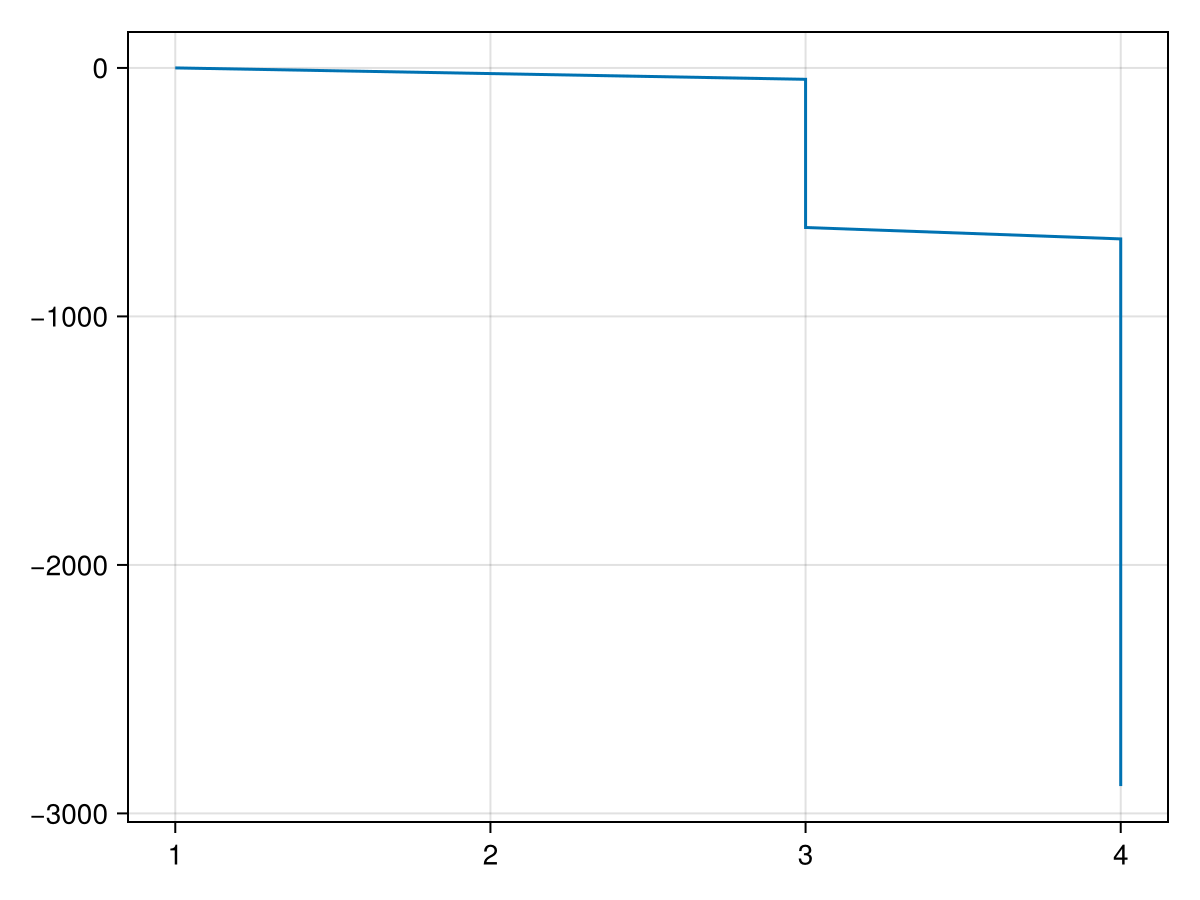

In [126]:
function get_phase(z)
    if z > -nondimensionalize(20e3m, CharDim)
        return 1 # upper crust
    elseif z > -nondimensionalize(40e3m, CharDim)
        return 2 # lower crust
    elseif z > -nondimensionalize(660e3m, CharDim)
        return 3 # upper mantle
    else
        return 4 # lower mantle
    end
end

phase = get_phase.(z)
lines(phase, @dimstrip(z, km, CharDim))


## Rheology

Rheologies from Table S2 of [Li et al 2026](https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2025JB032510?saml_referrer)

### Crust

In [133]:
rheo_upper_crust = nondimensionalize(DislocationCreep(
    A = 5.e-18Pa^(-23 // 10) / s,
    n = 2.3NoUnits,
    E = 154.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
), CharDim)

rheo_lower_crust = nondimensionalize(DislocationCreep(
    A = 2e-23Pa^(-32 // 10) / s,
    n = 3.2NoUnits,
    E = 238.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
), CharDim)

DislocationCreep: Name = , n=3.2, r=0.0, A=4.9232974057587794e14 Pa^-3.2 s^-1.0, E=9.860147888132396e-22 J mol^-1.0, V=3.314335424582318e-25 m^3.0 mol^-1.0, FT=1.0, FE=1.0, Apparatus=3

### Lithospheric mantle

In [139]:
disl_mantle = nondimensionalize(DislocationCreep(
    A = 1.1e-17Pa^(-35 // 10) / s,
    n = 3.5NoUnits,
    E = 530.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
), CharDim)
diff_mantle = nondimensionalize(DiffusionCreep(
    A = 2.2e-10Pa^(-1) * s^(-1),       # material specific rheological parameter
    E = 375e3J / mol,                  # activation energy
    V = 4e-6m^3 / mol,                 # activation Volume
    n = 1.0NoUnits,                    # power-law exponent
    r = 0.0NoUnits,                    # exponent of water-fugacity
    p = 0NoUnits,                      # grain size exponent
), CharDim)
rheo_mantle = CompositeRheology(disl_mantle, diff_mantle)

--⟦▪̲̅▫̲̅▫̲̅▫̲̅----⟦▪̲̅▫̲̅▫̲̅▫̲̅--


### Lower mantle

In [144]:
rheo_lower_mantle = nondimensionalize(DiffusionCreep(
    A = 2.2e-13Pa^(-1) * s^(-1),       # material specific rheological parameter
    E = 300e3J / mol,                  # activation energy
    V = 2e-6m^3 / mol,                 # activation Volume
    n = 1.0NoUnits,                    # power-law exponent
    r = 0.0NoUnits,                    # exponent of water-fugacity
    p = 0NoUnits,                      # grain size exponent
    Apparatus = Invariant,
), CharDim)


DiffusionCreep: Name = , n=1.0, r=0.0, p=0.0, A=2.156e9 Pa^-1.0 s^-1.0, E=1.242875784218369e-21 J mol^-1.0, V=8.285838561455795e-26 m^3.0 mol^-1.0, FT=1.0, FE=1.0

### Resulting rheology

In [148]:
rheology = rheo_upper_crust, rheo_lower_crust, rheo_mantle, rheo_lower_mantle;


# Compute viscosity profile with GeoParams

In [151]:
εII = nondimensionalize(1e-15 / s, CharDim)
η = zeros(n)
for i in eachindex(z)
    phaseᵢ = phase[i]
    Tᵢ = T[i]
    Pᵢ = P[i]
    args = (; T = Tᵢ, P = Pᵢ, dt = Inf)
    η[i] = clamp(
        compute_viscosity_εII(rheology[phaseᵢ], εII, args) * 2,
        nondimensionalize(1e18Pa * s, CharDim),
        nondimensionalize(1e23Pa * s, CharDim)
    )
end
η = @dimstrip η Pa * s CharDim;


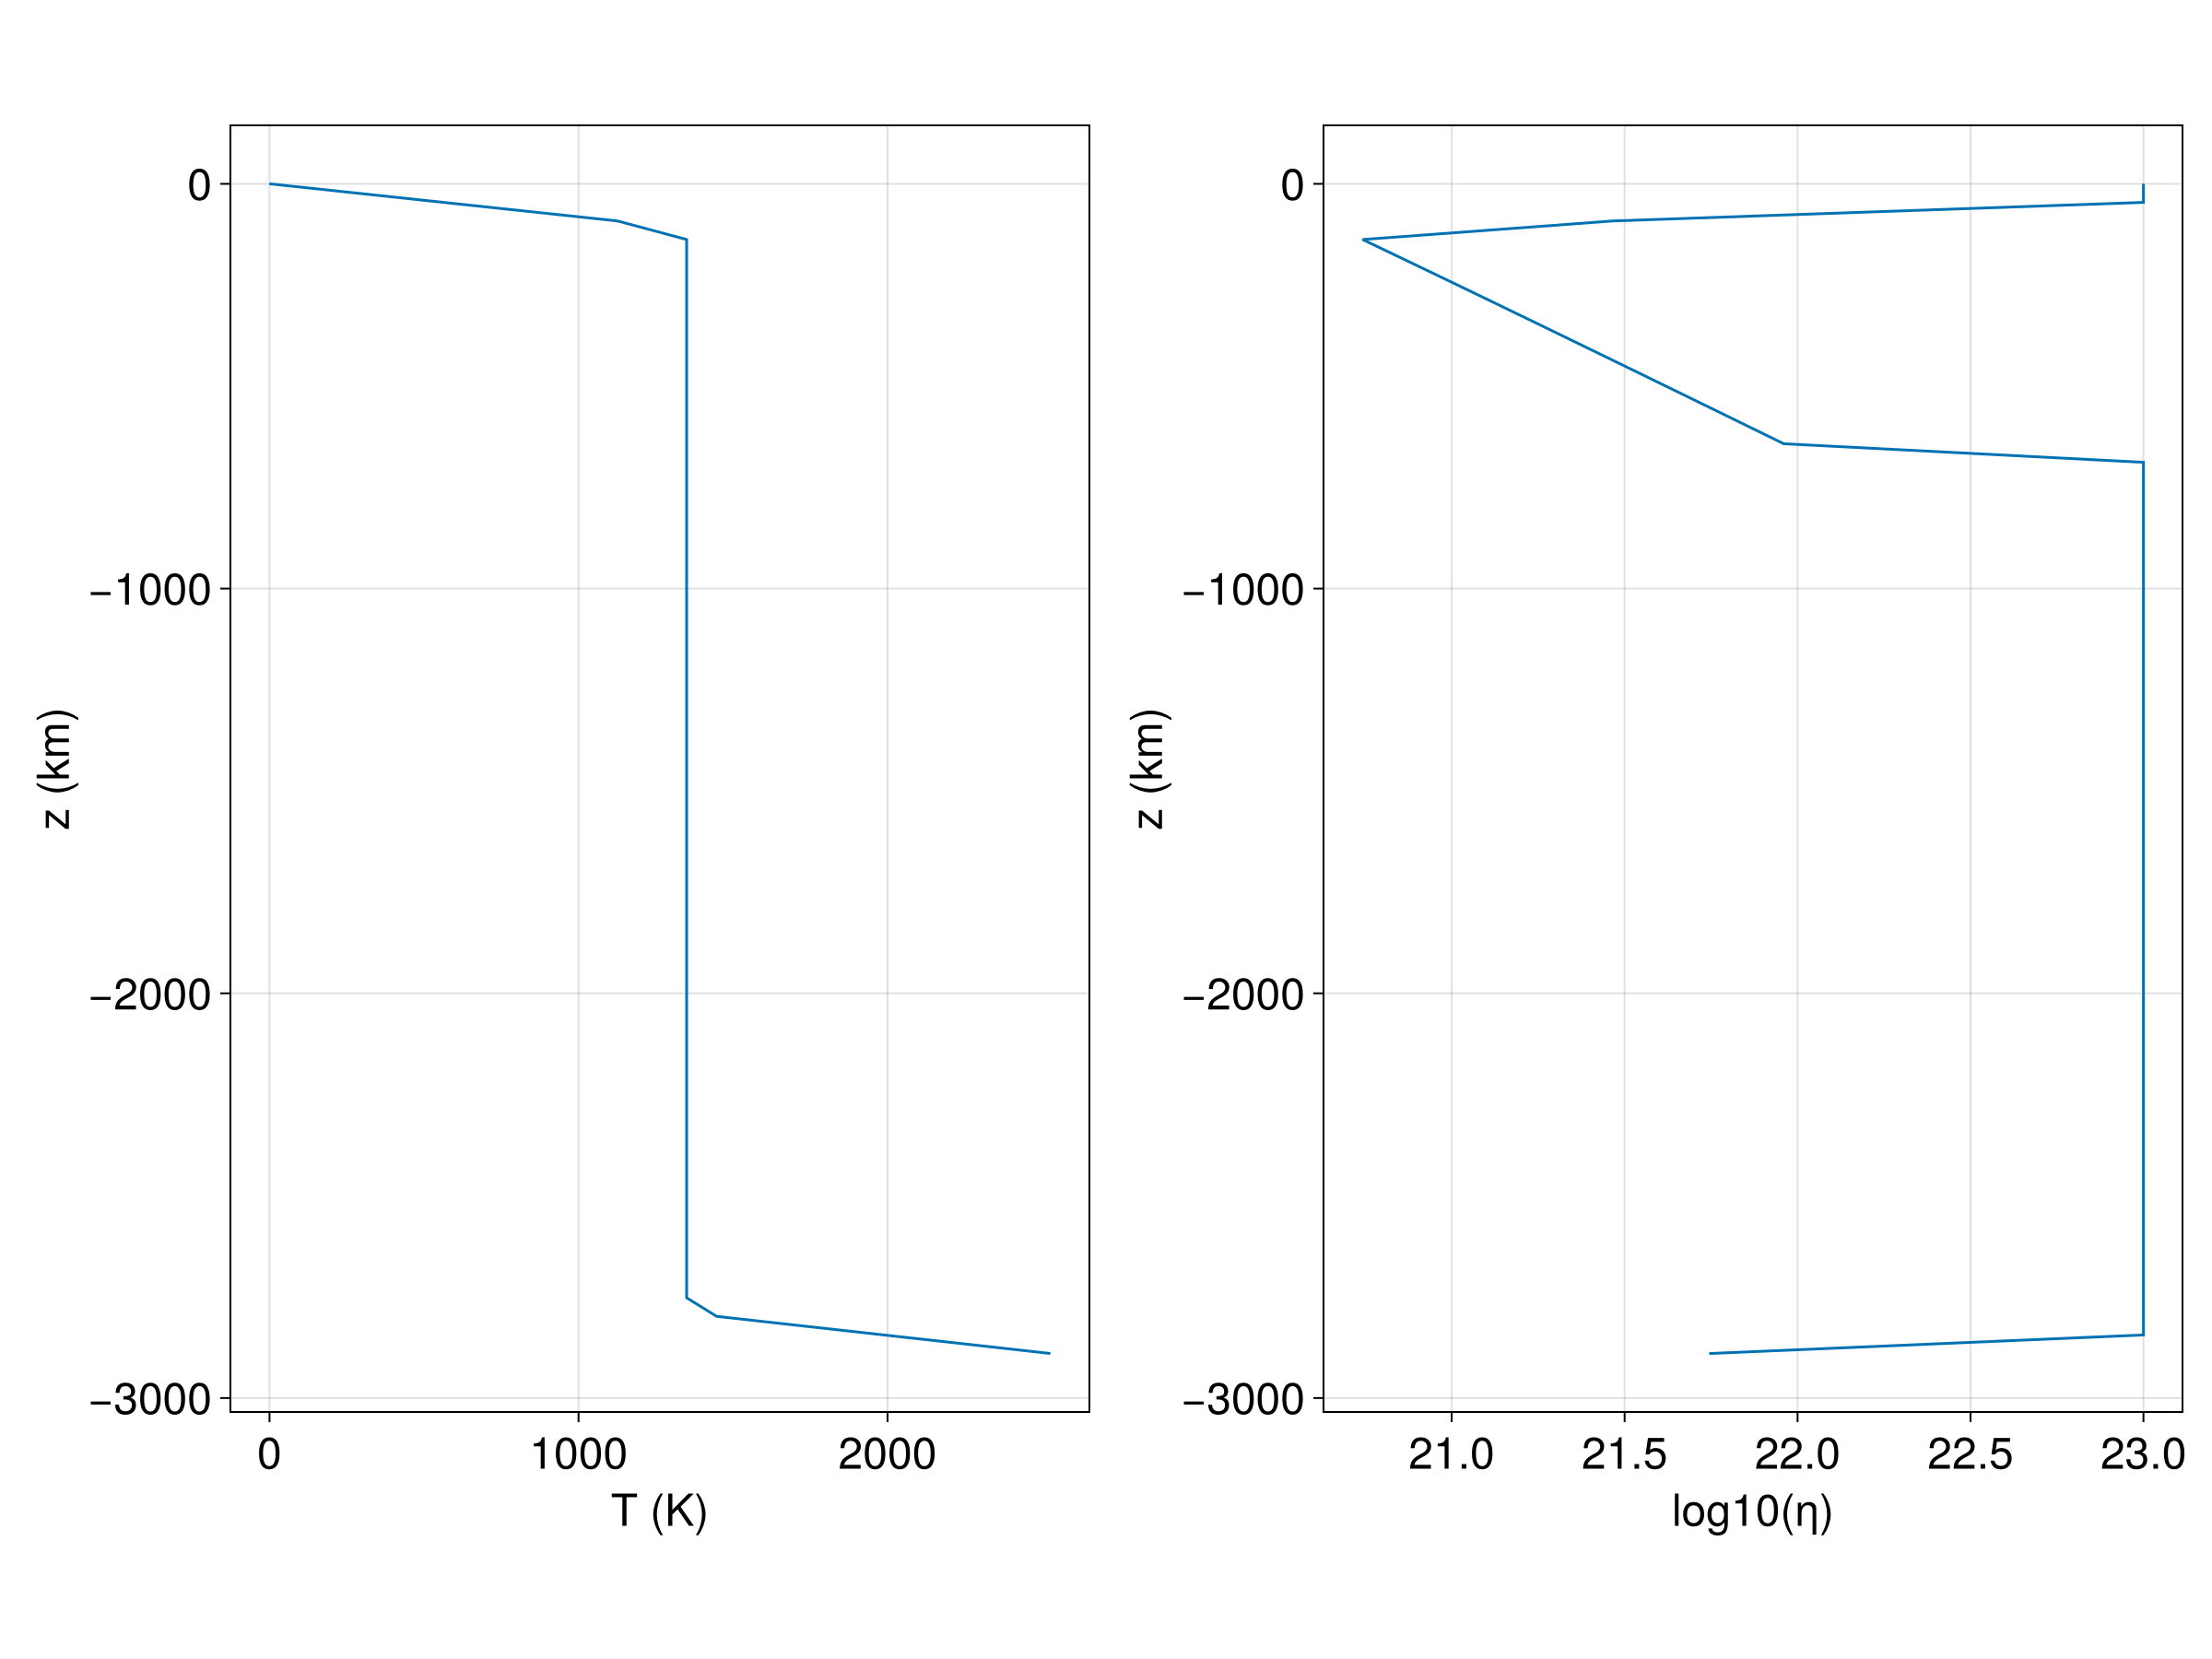

In [ ]:
fig = Figure(size = (1200, 900), fontsize = 24)
ax1 = Axis(fig[1, 1], aspect = 2 / 3, ylabel = "z (km)", xlabel = "T (K)")
ax2 = Axis(fig[1, 2], aspect = 2 / 3, ylabel = "z (km)", xlabel = "log10(η)")
lines!(ax1, 
    @dimstrip(T, C, CharDim), 
    @dimstrip(z, km, CharDim),
)
lines!(ax2, 
    log10.(η), 
    @dimstrip(z, km, CharDim),
)
xlims!(ax2, 19, 23.5)
fig